<a href="https://colab.research.google.com/github/siyal-sss/Cardiovascular-Risk-Prediction/blob/main/Project_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

df = pd.read_csv("Medicaldataset.csv")

df.head()

,Age,Gender,Heart rate,Systolic blood pressure,Diastolic blood pressure,Blood sugar,CK-MB,Troponin,Result
0,64,1,66,160,83,160.0,1.80,0.012,negative
1,21,1,94,98,46,296.0,6.75,1.060,positive
2,55,1,64,160,77,270.0,1.99,0.003,negative
3,64,1,70,120,55,270.0,13.87,0.122,positive
4,55,1,64,112,65,300.0,1.08,0.003,negative


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1319 entries, 0 to 1318
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       1319 non-null   int64  
 1   Gender                    1319 non-null   int64  
 2   Heart rate                1319 non-null   int64  
 3   Systolic blood pressure   1319 non-null   int64  
 4   Diastolic blood pressure  1319 non-null   int64  
 5   Blood sugar               1319 non-null   float64
 6   CK-MB                     1319 non-null   float64
 7   Troponin                  1319 non-null   float64
 8   Result                    1319 non-null   object 
dtypes: float64(3), int64(5), object(1)
memory usage: 92.9+ KB


In [ ]:
df.describe()

,Age,Gender,Heart rate,Systolic blood pressure,Diastolic blood pressure,Blood sugar,CK-MB,Troponin
count,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000
mean,56.191812,0.659591,78.336619,127.170584,72.269143,146.634344,15.274306,0.360942
std,13.647315,0.474027,51.630270,26.122720,14.033924,74.923045,46.327083,1.154568
min,14.000000,0.000000,20.000000,42.000000,38.000000,35.000000,0.321000,0.001000
25%,47.000000,0.000000,64.000000,110.000000,62.000000,98.000000,1.655000,0.006000
50%,58.000000,1.000000,74.000000,124.000000,72.000000,116.000000,2.850000,0.014000
75%,65.000000,1.000000,85.000000,143.000000,81.000000,169.500000,5.805000,0.085500
max,103.000000,1.000000,1111.000000,223.000000,154.000000,541.000000,300.000000,10.300000


In [ ]:
df.isnull().sum()

,0
Age,0
Gender,0
Heart rate,0
Systolic blood pressure,0
Diastolic blood pressure,0
Blood sugar,0
CK-MB,0
Troponin,0
Result,0


In [ ]:
df["Result"].value_counts()

,count
Result,
positive,810
negative,509


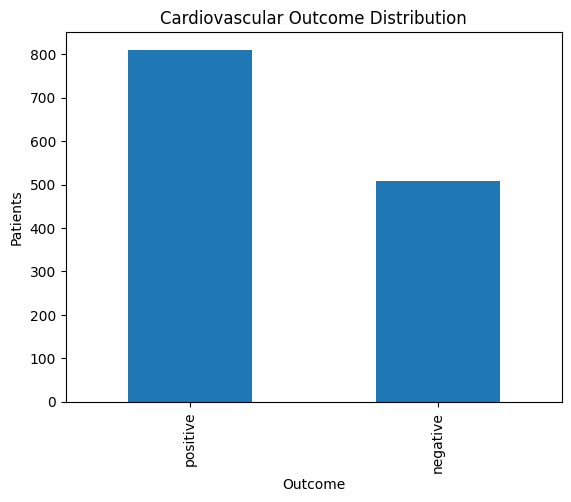

In [ ]:
import matplotlib.pyplot as plt

df["Result"].value_counts().plot(kind="bar")

plt.xlabel("Outcome")
plt.ylabel("Patients")
plt.title("Cardiovascular Outcome Distribution")

plt.savefig('cardiovascular_outcome_distribution.png')
plt.show()

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix

In [ ]:
df.columns

Index(['Age', 'Gender', 'Heart rate', 'Systolic blood pressure',
       'Diastolic blood pressure', 'Blood sugar', 'CK-MB', 'Troponin',
       'Result'],
      dtype='object')

In [ ]:
X = df.drop("Result", axis=1)

y = df["Result"]

In [ ]:
X = pd.get_dummies(X, drop_first=True)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [ ]:
lr = LogisticRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("Accuracy:", accuracy_score(y_test, lr_pred))

print(classification_report(y_test, lr_pred))

print("ROC-AUC:", roc_auc_score(y_test, lr.predict_proba(X_test)[:,1]))

Accuracy: 0.7992424242424242
              precision    recall  f1-score   support

    negative       0.76      0.69      0.73       101
    positive       0.82      0.87      0.84       163

    accuracy                           0.80       264
   macro avg       0.79      0.78      0.78       264
weighted avg       0.80      0.80      0.80       264

ROC-AUC: 0.8849237684504646


In [ ]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)


print("Accuracy:", accuracy_score(y_test, rf_pred))

print(classification_report(y_test, rf_pred))

print("ROC-AUC:", roc_auc_score(
    y_test,
    rf.predict_proba(X_test)[:,1]
))

Accuracy: 0.9810606060606061
              precision    recall  f1-score   support

    negative       0.98      0.97      0.98       101
    positive       0.98      0.99      0.98       163

    accuracy                           0.98       264
   macro avg       0.98      0.98      0.98       264
weighted avg       0.98      0.98      0.98       264

ROC-AUC: 0.9903116078479013


In [ ]:
gb = GradientBoostingClassifier()

gb.fit(X_train, y_train)

gb_pred = gb.predict(X_test)


print("Accuracy:", accuracy_score(y_test, gb_pred))

print(classification_report(y_test, gb_pred))

print("ROC-AUC:",
      roc_auc_score(
          y_test,
          gb.predict_proba(X_test)[:,1]
      ))

Accuracy: 0.9772727272727273
              precision    recall  f1-score   support

    negative       0.98      0.96      0.97       101
    positive       0.98      0.99      0.98       163

    accuracy                           0.98       264
   macro avg       0.98      0.97      0.98       264
weighted avg       0.98      0.98      0.98       264

ROC-AUC: 0.9885500820020654


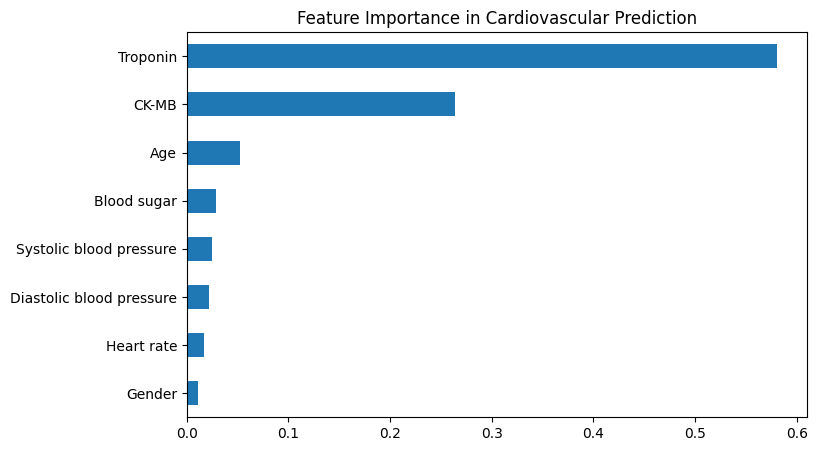

In [ ]:
import matplotlib.pyplot as plt


importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
)

importance.sort_values().plot(
    kind="barh",
    figsize=(8,5)
)

plt.title("Feature Importance in Cardiovascular Prediction")

plt.show()

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

In [ ]:
# Logistic Regression
lr_prob = lr.predict_proba(X_test)[:,1]

# Random Forest
rf_prob = rf.predict_proba(X_test)[:,1]

# Gradient Boosting
gb_prob = gb.predict_proba(X_test)[:,1]

In [ ]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

y_test_encoded = encoder.fit_transform(y_test)

In [ ]:
print(y_test.unique())
print(y_test_encoded[:10])

['positive' 'negative']
[1 0 0 0 1 1 1 1 1 1]


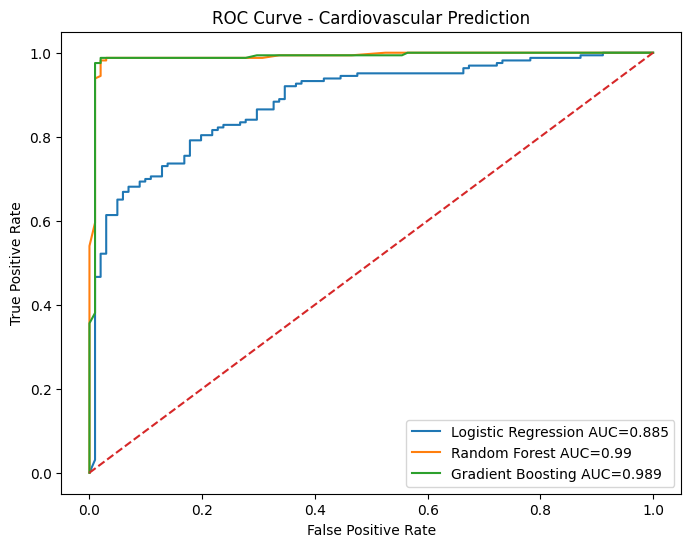

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt


plt.figure(figsize=(8,6))


# Logistic Regression
fpr, tpr, _ = roc_curve(y_test_encoded, lr_prob)
plt.plot(
    fpr,
    tpr,
    label="Logistic Regression AUC="+str(round(auc(fpr,tpr),3))
)


# Random Forest
fpr, tpr, _ = roc_curve(y_test_encoded, rf_prob)
plt.plot(
    fpr,
    tpr,
    label="Random Forest AUC="+str(round(auc(fpr,tpr),3))
)


# Gradient Boosting
fpr, tpr, _ = roc_curve(y_test_encoded, gb_prob)
plt.plot(
    fpr,
    tpr,
    label="Gradient Boosting AUC="+str(round(auc(fpr,tpr),3))
)


plt.plot([0,1],[0,1],'--')


plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Cardiovascular Prediction")

plt.legend()

plt.savefig('roc_curve_prediction.png')
plt.show()

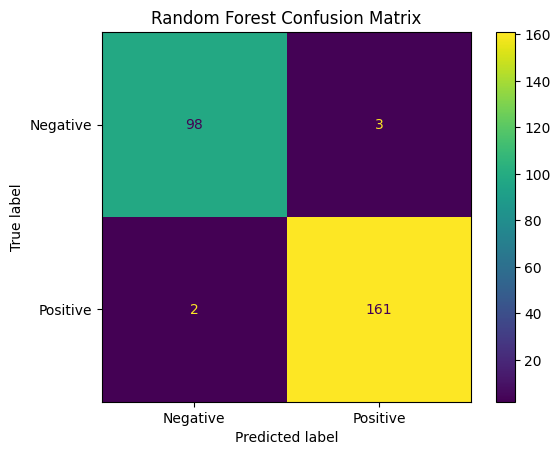

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, rf_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Negative","Positive"]
)

disp.plot()

plt.title("Random Forest Confusion Matrix")

plt.savefig('random_forest_confusion_matrix.png')
plt.show()

In [ ]:
print(f"Number of patients in the training set: {len(X_train)}")
print(f"Number of patients in the testing set: {len(X_test)}")
print(f"Total number of patients in the model: {len(X_train) + len(X_test)}")

Number of patients in the training set: 1055
Number of patients in the testing set: 264
Total number of patients in the model: 1319


In [ ]:
plt.savefig('random_forest_confusion_matrix.png')

<Figure size 640x480 with 0 Axes>

To save any plot, you can use the `plt.savefig()` function from Matplotlib after creating the plot and before `plt.show()`. For example, to save the ROC curve, you would add `plt.savefig('roc_curve.png')` after the ROC curve plot code.